In [1]:
#!/usr/bin/env python

'''
This script does 3 things:
1. Trains the resolvi model on the combined object
2. Extracts the latent representation and normalized expression from the model
3. Saves the updated combined object with the new data
'''


# %% Libraries
from matplotlib import use
import os
import json
import scanpy as sc
import numpy as np
from pathlib import Path
import rapids_singlecell as rsc
import scvi
import pandas as pd

# %% Setting Paths
# setting paths
MAIN_DIR_NAME = "cosmx_gray"
MAIN_DIR = next(p for p in Path.cwd().parents if (p / MAIN_DIR_NAME).exists()) / MAIN_DIR_NAME
os.chdir(MAIN_DIR)

# %% Setting Seed
SEED_VALUE = 42
# set NumPy RNG for consistency
np.random.seed(42)

# %% Setting scVI parameters
# scvi.settings.dl_num_workers = 4
# scvi.settings.dl_persistent_workers = True
# scvi.settings.seed = SEED_VALUE

# %% object versions
CUR_OBJ_V = 'refined-clustered'
CUR_OBJ_PATH = MAIN_DIR / 'data' / 'comb' / 'h5ad' / f'comb-{CUR_OBJ_V}.h5ad'

# %% Results Directories
RES_DIR = "/data/cosmx_gray/code/9_extra_analysis/resolvi_de"
#RES_DIR = Path(__file__).resolve().parent
print(RES_DIR)

# %% Load comb object 
comb = sc.read_h5ad(CUR_OBJ_PATH)


/data/cosmx_gray/code/9_extra_analysis/resolvi_de


In [2]:

# %% load resolvi model
scvi_model_path = MAIN_DIR / 'data/comb' / 'resolvi_model'
model = scvi.external.RESOLVI.load(scvi_model_path, adata=comb)


INFO     File /data/cosmx_gray/data/comb/resolvi_model/model.pt already         
         downloaded                                                             
RAPIDS SingleCell is installed and can be imported
RAPIDS SingleCell is installed and can be imported
RAPIDS SingleCell is installed and can be imported
RAPIDS SingleCell is installed and can be imported


/data/miniforge3/envs/rapids_singlecell/lib/python3.14/site-packages/scvi/data/fields/_dataframe_field.py:227: UserWarning: Category 0 in adata.obs['_scvi_ind_x'] has fewer than 3 cells. Models may not train properly.
  new_mapping = _make_column_categorical(
/data/miniforge3/envs/rapids_singlecell/lib/python3.14/site-packages/scvi/model/base/_save_load.py:158: FutureWarning: RESOLVI is a spatial transcriptomics model that will be moved to the scvi-tools spatial companion package `scviva-tools` starting in scvi-tools v1.5 and will no longer be supported here. It will be deprecated from scvi-tools in v1.6.
  model = cls(adata, **non_kwargs, **kwargs)
INFO: GPU available: True (cuda), used: True
2026-07-17 12:13:01 | [INFO] GPU available: True (cuda), used: True
INFO: TPU available: False, using: 0 TPU cores
2026-07-17 12:13:01 | [INFO] TPU available: False, using: 0 TPU cores
INFO: 💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/pro

Epoch 1/50:   0%|          | 0/50 [00:00<?, ?it/s]

/data/miniforge3/envs/rapids_singlecell/lib/python3.14/site-packages/scvi/external/resolvi/_module.py:383: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at /pytorch/torch/csrc/autograd/generated/python_variable_methods.cpp:838.)
  concentration=torch.tensor(
2026-07-17 12:13:03 | [INFO] Guessed max_plate_nesting = 2


Epoch 1/50:   2%|▏         | 1/50 [00:01<01:21,  1.67s/it, v_num=1]

INFO: `Trainer.fit` stopped: `max_steps=1` reached.
2026-07-17 12:13:04 | [INFO] `Trainer.fit` stopped: `max_steps=1` reached.


Epoch 1/50:   2%|▏         | 1/50 [00:01<01:27,  1.78s/it, v_num=1]
RESOLVI Model with the following params: 
n_hidden: 32 n_latent: 10, n_layers: 2, dropout_rate: 0.05, dispersion: gene, 
gene_likelihood: nb n_neighbors: 10
Training status: Trained


In [9]:
# Select only club cells
club_mask = (
    comb.obs["ann_lvl_3_refined"]
    .astype(str)
    .eq("dCil")
    .to_numpy()
)

# Check that both conditions contain club cells
print(
    comb.obs.loc[club_mask, "condition"]
    .value_counts()
)

# Club cells: CF versus CTRL
df_club_cf_vs_ctrl = model.differential_expression(
    adata=comb,                     # omit if model was initialized with comb
    groupby="condition",
    group1="CF",
    group2="CTRL",
    subset_idx=club_mask,
    mode="change",
    delta=0.25,
    fdr_target=0.05,
)

df_club_cf_vs_ctrl.head()

condition
CF      30363
CTRL      875
Name: count, dtype: int64
DE...: 100%|██████████| 1/1 [00:01<00:00,  1.90s/it]


,proba_de,proba_not_de,bayes_factor,scale1,scale2,pseudocounts,delta,lfc_mean,lfc_median,lfc_std,...,raw_mean1,raw_mean2,non_zeros_proportion1,non_zeros_proportion2,raw_normalized_mean1,raw_normalized_mean2,is_de_fdr_0.05,comparison,group1,group2
PLPP6,0.9892,0.0108,4.517349,5.238300e-06,0.000064,4.089783e-07,0.25,-3.597872,-3.606095,1.341420,...,0.028324,0.054857,0.025524,0.043429,2.019336,3.581124,True,CF vs CTRL,CF,CTRL
BCHE,0.9864,0.0136,4.283991,1.563975e-07,0.000011,4.089783e-07,0.25,-5.442822,-5.262448,2.229481,...,0.041630,0.053714,0.035174,0.044571,3.847264,5.410036,True,CF vs CTRL,CF,CTRL
SIRT1,0.9836,0.0164,4.093937,1.757473e-07,0.000005,4.089783e-07,0.25,-3.956798,-3.692947,1.969106,...,0.040938,0.069714,0.035405,0.056000,3.732686,6.138482,True,CF vs CTRL,CF,CTRL
DLG4,0.9830,0.0170,4.057395,2.115445e-03,0.000364,4.089783e-07,0.25,2.457386,2.451934,1.057286,...,0.192998,0.044571,0.147054,0.042286,14.288899,3.589961,True,CF vs CTRL,CF,CTRL
TM4SF1,0.9784,0.0216,3.813225,1.130025e-04,0.000797,4.089783e-07,0.25,-2.789951,-2.796292,1.234098,...,0.037908,0.173714,0.032704,0.129143,2.687391,12.605334,True,CF vs CTRL,CF,CTRL


RESOLVI Model with the following params: 
n_hidden: 32 n_latent: 10, n_layers: 2, dropout_rate: 0.05, dispersion: gene, 
gene_likelihood: nb n_neighbors: 10
Training status: Trained


In [10]:
lfc_threshold = 0.5

significant = df_club_cf_vs_ctrl[
    df_club_cf_vs_ctrl["is_de_fdr_0.05"].fillna(False)
].copy()

n_up = (
    significant["lfc_mean"] >= lfc_threshold
).sum()

n_down = (
    significant["lfc_mean"] <= -lfc_threshold
).sum()

print(f"Upregulated in CF: {n_up}")
print(f"Downregulated in CF: {n_down}")
print(f"Total significant: {n_up + n_down}")

Upregulated in CF: 20
Downregulated in CF: 45
Total significant: 65
RESOLVI Model with the following params: 
n_hidden: 32 n_latent: 10, n_layers: 2, dropout_rate: 0.05, dispersion: gene, 
gene_likelihood: nb n_neighbors: 10
Training status: Trained


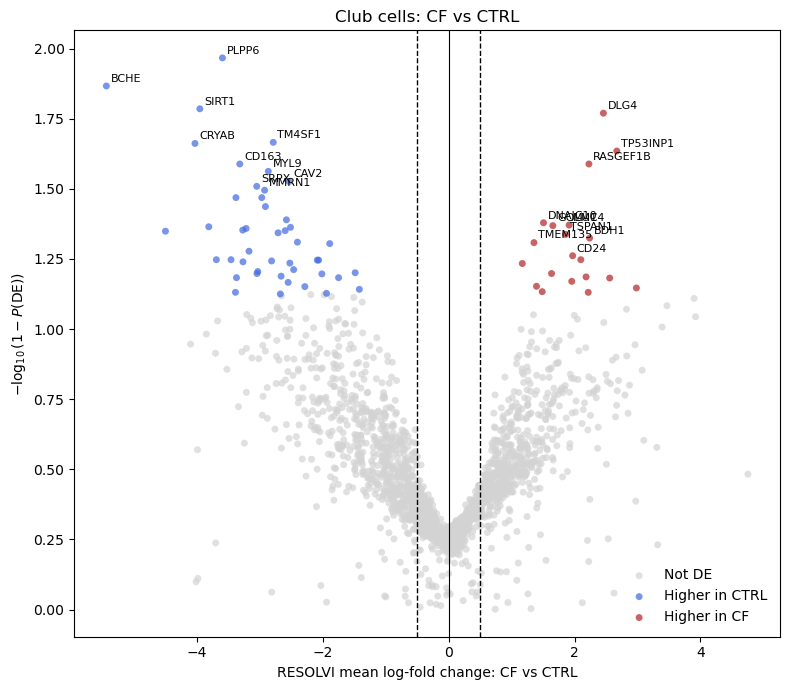

RESOLVI Model with the following params: 
n_hidden: 32 n_latent: 10, n_layers: 2, dropout_rate: 0.05, dispersion: gene, 
gene_likelihood: nb n_neighbors: 10
Training status: Trained


In [11]:
import numpy as np
import matplotlib.pyplot as plt

# Your RESOLVI DE result
volcano = df_club_cf_vs_ctrl.copy()

# Gene names are normally stored in the index
volcano["gene"] = volcano.index.astype(str)

# Convert posterior DE probability into a volcano-style score
volcano["de_score"] = -np.log10(
    np.clip(1 - volcano["proba_de"], 1e-300, 1)
)

# Thresholds
lfc_threshold = 0.5
fdr_col = "is_de_fdr_0.05"

# Classify genes
volcano["status"] = "Not DE"

volcano.loc[
    volcano[fdr_col].fillna(False)
    & (volcano["lfc_mean"] >= lfc_threshold),
    "status"
] = "Higher in CF"

volcano.loc[
    volcano[fdr_col].fillna(False)
    & (volcano["lfc_mean"] <= -lfc_threshold),
    "status"
] = "Higher in CTRL"

# Colours
colour_map = {
    "Not DE": "lightgrey",
    "Higher in CF": "firebrick",
    "Higher in CTRL": "royalblue",
}

# Plot
fig, ax = plt.subplots(figsize=(8, 7))

for status in ["Not DE", "Higher in CTRL", "Higher in CF"]:
    subset = volcano[volcano["status"] == status]

    ax.scatter(
        subset["lfc_mean"],
        subset["de_score"],
        s=25,
        alpha=0.7,
        color=colour_map[status],
        label=status,
        edgecolors="none",
    )

# LFC threshold lines
ax.axvline(
    lfc_threshold,
    linestyle="--",
    linewidth=1,
    color="black",
)

ax.axvline(
    -lfc_threshold,
    linestyle="--",
    linewidth=1,
    color="black",
)

ax.axvline(
    0,
    linestyle="-",
    linewidth=0.8,
    color="black",
)

# Label the strongest genes from both directions
genes_to_label = pd.concat([
    volcano[
        volcano["status"] == "Higher in CF"
    ].nlargest(10, "de_score"),

    volcano[
        volcano["status"] == "Higher in CTRL"
    ].nlargest(10, "de_score"),
])

for _, row in genes_to_label.iterrows():
    ax.annotate(
        row["gene"],
        (row["lfc_mean"], row["de_score"]),
        xytext=(3, 3),
        textcoords="offset points",
        fontsize=8,
    )

ax.set_xlabel("RESOLVI mean log-fold change: CF vs CTRL")
ax.set_ylabel(r"$-\log_{10}(1 - P(\mathrm{DE}))$")
ax.set_title("Club cells: CF vs CTRL")
ax.legend(frameon=False)

plt.tight_layout()
plt.show()